# ACT Playground -- Action Chunking Transformer

```bash
cd ~/robot
nix develop --command jupyter lab
```

ACT predicts a **chunk** of the next *k* actions from a CVAE, and **temporal-ensembles**
overlapping chunks at rollout. Three levers against compounding error, all different
from the GMM head:
- **Action chunking** -- commit to *k* steps at once, cutting the effective horizon ~k x.
- **CVAE latent z** -- a per-chunk latent absorbs demo multimodality so the decoder is
  cleanly conditioned (the encoder is train-only; z=0 at test).
- **Temporal ensembling** -- blend the overlapping predictions for each step -> smoother.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os, numpy as np, torch
import act_harness as AH

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# Same toggle as the BC notebook: "ph" (single expert) or "mh" (multi-human, multimodal).
TASK, SPLIT = "can", "mh"
CHUNK = 16                     # k: how many future actions each prediction covers
DATASET = os.path.join("robomimic", "datasets", TASK, SPLIT, "low_dim_v15.hdf5")
data = AH.load_chunk_dataset(DATASET, chunk_size=CHUNK)
print(f"{data.n_demos} demos | {data.states.shape[0]} chunks | obs_dim={data.obs_dim} "
      f"act_dim={data.action_dim} chunk={data.chunk_size}")
print("obs keys:", data.obs_keys)

device: cuda | NVIDIA GeForce GTX 1060 6GB
300 demos | 62756 chunks | obs_dim=23 act_dim=7 chunk=16
obs keys: ('robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos', 'object')


### Architecture

**Encoder (posterior `q(z | state, chunk)`, train only):** a transformer over the tokens
`[CLS, state, a_1 .. a_k]`; the `CLS` output is mapped to `(mu, logvar)` of a latent `z`.
Padded action steps are masked out.

**Decoder (`p(chunk | state, z)`):** memory tokens `[z, state]`; `k` learned query
embeddings cross-attend to that memory and decode the `k` actions.

**Loss (ELBO):** `L1(pred_chunk, expert_chunk)` (masked by `is_pad`) `+ beta * KL(q(z|.) || N(0,I))`.
`beta` (=`kl_weight`) keeps the latent close to the prior so that `z = 0` is a sensible
default at test time.

In [ ]:
import torch, torch.nn as nn, torch.nn.functional as F


class ACTPolicy(nn.Module):
    """State-based ACT (CVAE over action chunks). Harness contract: compute_loss / predict_chunk."""
    def __init__(self, obs_dim, action_dim, chunk_size, *, d_model=256, nhead=8,
                 enc_layers=4, dec_layers=6, dim_ff=1024, latent_dim=32, dropout=0.1):
        super().__init__()
        self.k, self.latent_dim = chunk_size, latent_dim

        # --- CVAE encoder (posterior q(z | state, chunk)); train-time only ---
        self.cls        = nn.Parameter(torch.zeros(1, 1, d_model))
        self.enc_action = nn.Linear(action_dim, d_model)
        self.enc_state  = nn.Linear(obs_dim, d_model)
        self.enc_pos    = nn.Parameter(torch.zeros(1, chunk_size + 2, d_model))   # [CLS, state, a_1..a_k]
        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_ff, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, enc_layers, enable_nested_tensor=False)  # skip nested-tensor fast path (silences the prototype warning)
        self.to_latent = nn.Linear(d_model, 2 * latent_dim)                       # CLS -> (mu, logvar)

        # --- decoder p(chunk | state, z) ---
        self.z_to_mem  = nn.Linear(latent_dim, d_model)
        self.st_to_mem = nn.Linear(obs_dim, d_model)
        self.mem_pos   = nn.Parameter(torch.zeros(1, 2, d_model))                 # [z, state]
        self.query     = nn.Parameter(torch.zeros(1, chunk_size, d_model))        # k action queries
        dec_layer = nn.TransformerDecoderLayer(d_model, nhead, dim_ff, dropout, batch_first=True)
        self.decoder = nn.TransformerDecoder(dec_layer, dec_layers)
        self.action_head = nn.Linear(d_model, action_dim)

        for p in (self.cls, self.enc_pos, self.mem_pos, self.query):
            nn.init.normal_(p, std=0.02)

    def encode(self, s, a, is_pad):
        B = s.shape[0]
        x = torch.cat([self.cls.expand(B, -1, -1),
                       self.enc_state(s).unsqueeze(1),
                       self.enc_action(a)], dim=1) + self.enc_pos
        pad = torch.cat([torch.zeros(B, 2, dtype=torch.bool, device=s.device), is_pad], dim=1)
        cls_out = self.encoder(x, src_key_padding_mask=pad)[:, 0]
        mu, logvar = self.to_latent(cls_out).chunk(2, dim=-1)
        return mu, logvar

    def decode(self, s, z):
        B = s.shape[0]
        mem = torch.cat([self.z_to_mem(z).unsqueeze(1),
                         self.st_to_mem(s).unsqueeze(1)], dim=1) + self.mem_pos
        h = self.decoder(self.query.expand(B, -1, -1), mem)
        return self.action_head(h)                                                # [B, k, action_dim]

    def compute_loss(self, s, a, is_pad, *, kl_weight=10.0):
        mu, logvar = self.encode(s, a, is_pad)
        z = mu + torch.randn_like(mu) * torch.exp(0.5 * logvar)                    # reparameterization
        pred = self.decode(s, z)
        l1 = F.l1_loss(pred, a, reduction="none").mean(-1)                         # [B, k]
        keep = (~is_pad).float()
        recon = (l1 * keep).sum() / keep.sum().clamp(min=1)                        # ignore padded steps
        kl = (-0.5 * (1 + logvar - mu.pow(2) - logvar.exp())).sum(-1).mean()
        total = recon + kl_weight * kl
        return total, {"recon": float(recon.item()), "kl": float(kl.item())}

    @torch.no_grad()
    def predict_chunk(self, s):
        z = torch.zeros(s.shape[0], self.latent_dim, device=s.device)             # z = 0 at test time
        return self.decode(s, z)


policy = ACTPolicy(data.obs_dim, data.action_dim, data.chunk_size,
                   d_model=128, enc_layers=2, dec_layers=4, dim_ff=512)
print(policy.__class__.__name__, "| params:",
      round(sum(p.numel() for p in policy.parameters()) / 1e6, 2), "M")

ACTPolicy | params: 1.48 M


## 2. Train (ELBO)

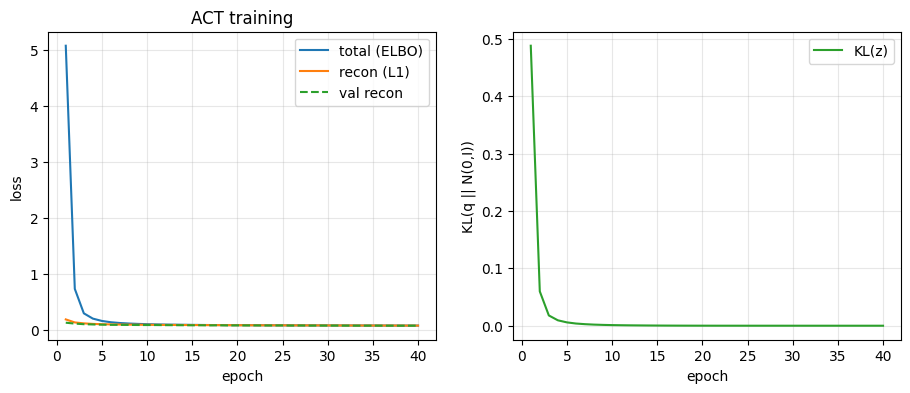

final recon (L1): 0.08047 | final KL: 0.0


In [4]:
history = AH.train_act(
    policy, data,
    epochs=40, batch_size=256, lr=1e-4, weight_decay=1e-4,
    kl_weight=10.0, device=device, plot=True, plot_every=2, val_frac=0.1,
)
print("final recon (L1):", round(history["recon"][-1], 5), "| final KL:", round(history["kl"][-1], 4))

## 3. Rollout (temporal ensembling)


In [ ]:
env = AH.make_env(data, render=True)   # build once; reuse below

out = AH.rollout_act(policy, env, data, horizon=400, temporal_agg=True, m=0.01,
                     device=device, render=False)
print(f"success={out['success']}  length={out['length']}  return={out['total_reward']:.1f}")

clip = AH.rollout_act(policy, env, data, horizon=300, temporal_agg=True, m=0.01,
                      device=device, render=True, img_hw=(160, 160))
AH.save_gif(clip["frames"], "media/act_rollout.gif", fps=12, max_frames=90)

![act_rollout](media/act_rollout.gif)

## 4. Success rate over many episodes

In [ ]:
res = AH.evaluate_act(policy, env, data, n_episodes=20, horizon=400,
                      temporal_agg=True, m=0.01, device=device, render_n=6, img_hw=(96, 96))
print(f"success rate over {len(res['episodes'])} episodes: {res['success_rate']*100:.1f}%")
AH.save_gif_grid([e for e in res["episodes"] if e["frames"]], "media/act_grid.gif", ncols=3, fps=8, max_frames=48, scale=0.9)

![act_grid](media/act_grid.gif)

### Ablation: temporal ensembling on vs off


In [7]:
for ta in (True, False):
    r = AH.evaluate_act(policy, env, data, n_episodes=20, horizon=400,
                        temporal_agg=ta, m=0.01, device=device, render_first=False)
    print(f"temporal_agg={ta!s:5} -> success {r['success_rate']*100:.1f}%")

temporal_agg=True  -> success 100.0%
temporal_agg=False -> success 100.0%
